<a href="https://colab.research.google.com/github/gabrieladamasceno/Tree-Models/blob/main/5GNIDD/Graphs_5GNIDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io

#Dataset Zero-Day

In [2]:
df_test = '''
Model,Ataque Zero-Day,Accuracy,F1,Precision,Recall,Time,CPU,Memory,Energy,ZD - Accuracy,ZD - F1,ZD - Precision,ZD - Recall,ZD - Time,ZD - CPU,ZD - Memory,ZD - Energy
Decision Tree,ICMPFlood,0.999502,0.99959,0.999559,0.99962,1.13576,1.47273,3152.91,2.90231e-05,1.0,1.0,1,1.0,1.11197,0.781818,3155.88,4.2511e-06
Decision Tree,UDPFlood,0.623819,0.550262,0.998965,0.379709,1.13215,0.781818,2993.85,4.32822e-06,0.0,0.0,1,0.0,1.11886,7.72727,2994.2,0.00412994
Decision Tree,SYNFlood,0.996973,0.997498,0.999557,0.995447,1.13525,0.672727,3422.34,2.76503e-06,0.679521,0.809184,1,0.679521,1.11178,1.13636,3422.36,1.30516e-05
Decision Tree,SYNScan,0.99949,0.999579,0.999552,0.999606,1.13532,1.03636,3339.82,1.01099e-05,1.0,1.0,1,1.0,1.11226,0.9,3339.82,6.48668e-06
Decision Tree,HTTPFlood,0.987429,0.989525,0.999592,0.979659,1.13552,0.809091,3264.67,4.81147e-06,0.895501,0.94487,1,0.895501,1.11533,0.463636,3264.67,8.89258e-07
Decision Tree,UDPScan,0.999502,0.99959,0.999559,0.99962,1.13639,2.61818,3255.81,0.000163161,1.0,1.0,1,1.0,1.11261,2.95455,3255.81,0.000229565
Decision Tree,TCPConnectScan,0.984205,0.986798,0.999951,0.973986,1.13489,0.790909,3335.09,4.49184e-06,0.0676042,0.126647,1,0.0676042,1.11256,0.790909,3335.09,4.40344e-06
Decision Tree,SlowrateDoS,0.99949,0.999579,0.999539,0.99962,1.13453,0.572727,3324.33,1.7051e-06,1.0,1.0,1,1.0,1.11319,1.01818,3324.33,9.40013e-06
Random Forest,ICMPFlood,0.999761,0.999803,0.99998,0.999627,2.55988,1.12727,3120.73,2.93357e-05,1.0,1.0,1,1.0,1.19521,0.781818,3123.7,4.56933e-06
Random Forest,UDPFlood,0.626928,0.555382,0.999982,0.384452,2.2913,0.563636,3010.02,3.28222e-06,0.00764595,0.0151759,1,0.00764595,1.55178,1.00909,3010.04,1.27559e-05
Random Forest,SYNFlood,0.997232,0.997712,0.99998,0.995454,2.55693,0.563636,3422.0,3.66273e-06,0.679521,0.809184,1,0.679521,1.21053,1.12727,3422.0,1.38724e-05
Random Forest,SYNScan,0.999757,0.9998,0.99998,0.99962,2.50366,0.563636,3329.74,3.58643e-06,1.0,1.0,1,1.0,1.21325,0.681818,3329.74,3.07641e-06
Random Forest,HTTPFlood,0.963282,0.968763,0.999978,0.939437,2.49788,5.96364,3254.35,0.00423834,0.685012,0.813065,1,0.685012,1.33202,0.681818,3254.35,3.37757e-06
Random Forest,UDPScan,0.999544,0.999623,0.99998,0.999267,2.47079,2.24545,3329.06,0.000223789,0.983401,0.991631,1,0.983401,1.21495,15.0273,3329.06,0.0329828
Random Forest,TCPConnectScan,0.983181,0.98593,0.999986,0.972263,2.41325,12.1,3325.68,0.0342018,0.00493462,0.00982077,1,0.00493462,1.2189,0.681818,3325.68,3.09076e-06
Random Forest,SlowrateDoS,0.999704,0.999756,0.999973,0.999539,2.51673,11.2455,3330.22,0.0286324,0.999173,0.999586,1,0.999173,1.26157,1.01818,3330.22,1.06532e-05
Catboost,ICMPFlood,0.9997,0.999752,0.999986,0.999518,3.59186,11.4364,3428.5,0.0429806,1.0,1.0,1,1.0,1.1233,1.33636,3363.05,2.14467e-05
Catboost,UDPFlood,0.624045,0.550406,0.999964,0.379702,3.43208,4.09091,3253.06,0.00187978,0.0,0.0,1,0.0,2.0261,11.1455,3208.15,0.0224411
Catboost,SYNFlood,0.997216,0.997698,0.99998,0.995427,3.47597,10.4545,3739.56,0.0317747,0.679521,0.809184,1,0.679521,1.14063,0.790909,3677.11,4.51454e-06
Catboost,SYNScan,0.999724,0.999773,0.999973,0.999573,3.4588,0.563636,3691.31,4.95464e-06,0.998973,0.999486,1,0.998973,1.16273,0.672727,3637.44,2.83196e-06
Catboost,HTTPFlood,0.999692,0.999746,0.999986,0.999505,3.41051,2.94545,3546.25,0.000697215,1.0,1.0,1,1.0,1.43283,14.9727,3497.13,0.0384759
Catboost,UDPScan,0.999523,0.999606,0.999973,0.99924,3.46373,8.37273,3622.46,0.0162643,0.983401,0.991631,1,0.983401,1.15318,0.990909,3564.37,8.97608e-06
Catboost,TCPConnectScan,0.998137,0.998461,0.999993,0.996933,3.43445,1.35455,3707.27,6.82854e-05,0.903035,0.949047,1,0.903035,1.16323,1.23636,3632.78,1.75871e-05
Catboost,SlowrateDoS,0.999745,0.99979,0.99998,0.9996,3.44284,1.36364,3578.06,6.98398e-05,1.0,1.0,1,1.0,1.26872,1.91818,3520.78,7.16348e-05
MLP,ICMPFlood,0.997492,0.997927,0.999721,0.996139,9.55611,3.29091,3283.37,0.0027247,0.0,0.0,1,0.0,1.78034,4.56364,3244.33,0.00135371
MLP,UDPFlood,0.623741,0.550184,0.998733,0.379668,10.03,1.8,3222.18,0.000467958,0.0,0.0,1,0.0,4.77848,3.01818,3231.51,0.00105103
MLP,SYNFlood,0.996636,0.99723,0.995557,0.998908,10.3845,2.28182,3657.51,0.000987005,0.999479,0.999739,1,0.999479,1.8722,6.99091,3352.99,0.00511733
MLP,SYNScan,0.997467,0.997908,0.998885,0.996933,10.0483,2.50909,3506.02,0.00126979,0.998716,0.999358,1,0.998716,1.97716,0.790909,3506.15,7.8255e-06
MLP,HTTPFlood,0.916205,0.925905,0.997571,0.863845,10.1999,1.90909,3443.63,0.000567762,0.301069,0.462802,1,0.301069,2.80644,7.18182,3313.47,0.00831667
MLP,UDPScan,0.998524,0.998782,0.998664,0.998901,9.85383,2.4,3534.12,0.00108975,0.99906,0.99953,1,0.99906,1.88766,2.98182,3534.95,0.000400367
MLP,TCPConnectScan,0.99722,0.997708,0.997342,0.998073,9.90925,3.1,3574.23,0.00236165,0.977301,0.98852,1,0.977301,1.95573,0.9,3453.97,1.14058e-05
MLP,SlowrateDoS,0.968961,0.973774,0.997928,0.950761,9.80359,3.42727,3527.18,0.00315734,0.526857,0.690119,1,0.526857,2.29626,0.918182,3528.03,1.42199e-05
Autoencoder,ICMPFlood,0.494268,0.447166,0.662511,0.337472,8.85588,3.19091,3228.06,0.00230179,1.0,1.0,1,1.0,1.86609,1.58182,3318.06,5.9087e-05
Autoencoder,UDPFlood,0.326987,0.159613,0.328153,0.105452,9.10445,2.97273,2969.87,0.00191341,0.000557859,0.0011151,1,0.000557859,4.51718,1.13636,2959.19,5.30285e-05
Autoencoder,SYNFlood,0.492906,0.446978,0.659197,0.338124,9.99661,1.83636,3334.31,0.000495243,0.863992,0.927034,1,0.863992,2.01792,3.32727,3301.52,0.000594647
Autoencoder,SYNScan,0.490053,0.445522,0.653257,0.338029,9.59136,1.47273,3345.63,0.000245096,0.84566,0.916377,1,0.84566,2.10951,8.1,3292.83,0.00896862
Autoencoder,HTTPFlood,0.478904,0.467958,0.613805,0.378114,9.27195,2.3,3261.9,0.000902495,1.0,1.0,1,1.0,2.85076,0.545455,3145.82,3.70106e-06
Autoencoder,UDPScan,0.490205,0.445397,0.653736,0.337757,10.3073,2.83636,3497.23,0.00188156,0.89477,0.944463,1,0.89477,2.02821,0.9,3460.66,1.18285e-05
Autoencoder,TCPConnectScan,0.497701,0.448278,0.67049,0.336692,9.78543,2.47273,3509.46,0.00118358,0.0276339,0.0537815,1,0.0276339,2.08884,0.672727,3475.33,5.08759e-06
Autoencoder,SlowrateDoS,0.476918,0.445835,0.62283,0.347175,9.80581,0.909091,3379.24,5.8938e-05,1.0,1.0,1,1.0,2.47243,4.69091,3416.95,0.00204167
'''

In [3]:
# Configura para mostrar todas as linhas e colunas
pd.set_option('display.max_rows', None)  # None retira o limite de linhas
pd.set_option('display.max_columns', None) # None retira o limite de colunas
pd.set_option('display.width', 1000)      # Evita quebra de linha no console

df = pd.read_csv(io.StringIO(df_test))

print("DataFrame Inteiro:")
print(df)

DataFrame Inteiro:
            Model Ataque Zero-Day  Accuracy        F1  Precision    Recall      Time        CPU   Memory    Energy  ZD - Accuracy   ZD - F1  ZD - Precision  ZD - Recall  ZD - Time   ZD - CPU  ZD - Memory   ZD - Energy
0   Decision Tree       ICMPFlood  0.999502  0.999590   0.999559  0.999620   1.13576   1.472730  3152.91  0.000029       1.000000  1.000000               1     1.000000    1.11197   0.781818      3155.88  4.251100e-06
1   Decision Tree        UDPFlood  0.623819  0.550262   0.998965  0.379709   1.13215   0.781818  2993.85  0.000004       0.000000  0.000000               1     0.000000    1.11886   7.727270      2994.20  4.129940e-03
2   Decision Tree        SYNFlood  0.996973  0.997498   0.999557  0.995447   1.13525   0.672727  3422.34  0.000003       0.679521  0.809184               1     0.679521    1.11178   1.136360      3422.36  1.305160e-05
3   Decision Tree         SYNScan  0.999490  0.999579   0.999552  0.999606   1.13532   1.036360  3339.82  0.0

In [4]:
attack_mapping = {
    'ICMPFlood': 'ICMP Flood',
    'UDPFlood': 'UDP Flood',
    'SYNFlood': 'SYN Flood',
    'SYNScan': 'SYN Scan',
    'HTTPFlood': 'HTTP Flood',
    'UDPScan': 'UDP Scan',
    'TCPConnectScan': 'TCP Connect Scan',
    'SlowrateDoS': 'Slow Rate DoS'
}

df['Ataque Zero-Day'] = df['Ataque Zero-Day'].map(attack_mapping)

In [5]:
data_for_heatmap = df[['Model', 'Ataque Zero-Day', 'Accuracy', 'ZD - Accuracy']]
data_for_heatmap = data_for_heatmap.rename(columns={'ZD - Accuracy': 'Accuracy Zero-Day', 'Ataque Zero-Day': 'Attack Zero-Day'})

In [6]:
df_melted = data_for_heatmap.melt(
    id_vars=['Model', 'Attack Zero-Day'],
    value_vars=['Accuracy', 'Accuracy Zero-Day'],
    var_name='Scenario',
    value_name='Accuracy Value'
)

df_pivot = df_melted.pivot_table(
    index='Attack Zero-Day',
    columns=['Model', 'Scenario'],
    values='Accuracy Value'
)


# Dataset Training vs Test

In [7]:
df_train_string = '''
Model,attack,total_time_train,avg_cpu_train,avg_mem_train,energy_train
Decision Tree,ICMPFlood,9.08841,49.95,3130.22,9.06117
Decision Tree,UDPFlood,6.97851,49.95,2988.01,6.9576
Decision Tree,SYNFlood,8.94428,50.0,3422.33,8.94428
Decision Tree,SYNScan,9.10166,49.95,3339.81,9.07438
Decision Tree,HTTPFlood,7.16761,49.75,3264.66,7.06063
Decision Tree,UDPScan,11.8248,50.0,3255.81,11.8248
Decision Tree,TCPConnectScan,8.8405,50.0,3335.09,8.8405
Decision Tree,SlowrateDoS,8.66296,50.0,3324.33,8.66296
Random Forest,ICMPFlood,140.608,49.95,3102.72,140.187
Random Forest,UDPFlood,94.1844,49.9,2995.44,93.6204
Random Forest,SYNFlood,156.284,49.9,3421.97,155.348
Random Forest,SYNScan,134.99,49.7,3329.73,132.575
Random Forest,HTTPFlood,100.147,49.9,3254.34,99.5477
Random Forest,UDPScan,136.851,49.95,3329.04,136.441
Random Forest,TCPConnectScan,129.417,49.85,3325.66,128.256
Random Forest,SlowrateDoS,115.615,49.95,3330.21,115.269
Catboost,ICMPFlood,103.356,98.9,3805.42,799.864
Catboost,UDPFlood,60.9728,99.3,3653.43,477.61
Catboost,SYNFlood,103.621,98.9,3834.76,801.915
Catboost,SYNScan,104.656,98.8,3888.04,807.468
Catboost,HTTPFlood,80.7903,98.9,3677.76,625.227
Catboost,UDPScan,103.691,98.85,3828.5,801.234
Catboost,TCPConnectScan,92.9354,99.1,3890.44,723.589
Catboost,SlowrateDoS,94.8382,98.9,3863.98,733.943
MLP,ICMPFlood,219.89,1.245,3477.4,0.00339471
MLP,UDPFlood,150.84,1.56,3214.05,0.00458121
MLP,SYNFlood,109.886,0.5,3588.05,0.000109886
MLP,SYNScan,110.636,0.25,3633.24,1.38295e-05
MLP,HTTPFlood,93.9596,2.8,3506.46,0.0165008
MLP,UDPScan,105.671,2.95,3730.24,0.0217027
MLP,TCPConnectScan,107.1,0.63,3709.81,0.000214241
MLP,SlowrateDoS,101.682,1.87,3707.1,0.00531933
Autoencoder,ICMPFlood,267.063,2.89167,2847.96,0.0516593
Autoencoder,UDPFlood,213.499,1.8225,2872.94,0.0103392
Autoencoder,SYNFlood,84.2763,0.51,3369.26,8.94347e-05
Autoencoder,SYNScan,88.0945,0.38,3516.84,3.86714e-05
Autoencoder,HTTPFlood,72.9844,4.6,3396.27,0.0568321
Autoencoder,UDPScan,87.0829,3.53,3636.1,0.0306441
Autoencoder,TCPConnectScan,87.4253,6.69,3687.86,0.209414
Autoencoder,SlowrateDoS,81.7727,3.76,3629.91,0.0347746
'''

# Paper


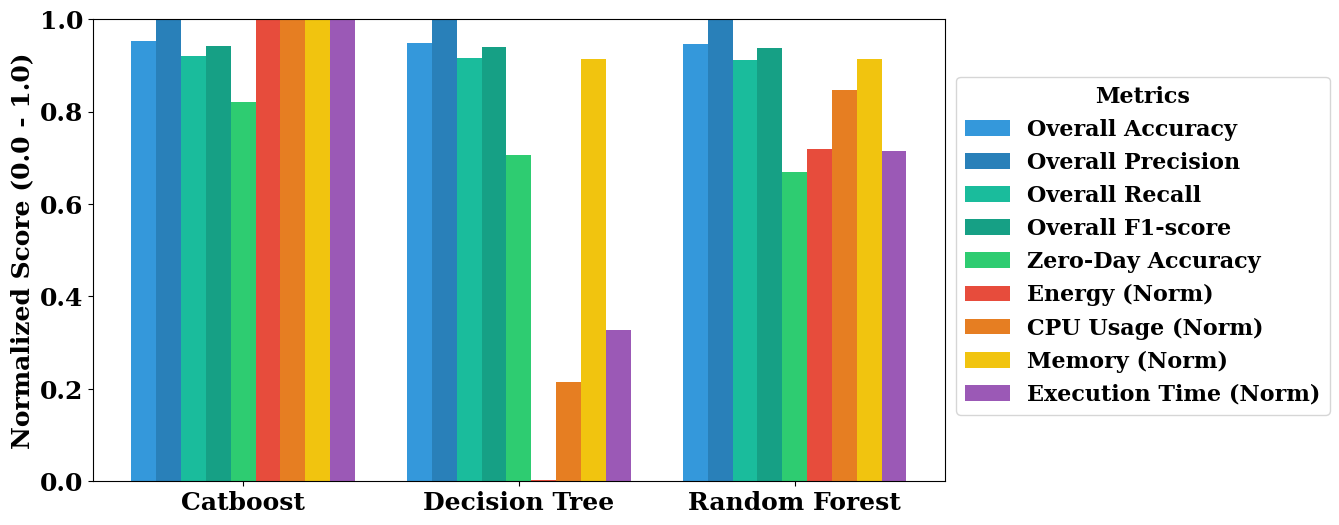

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.sans-serif": ["Liberation Serif"],
    "font.weight": "bold",
    "axes.labelweight": "bold",
})

models_to_keep = ['Catboost', 'Decision Tree', 'Random Forest']
df_filtered = df[df['Model'].isin(models_to_keep)].copy()

df_summary = df_filtered.groupby('Model').agg({
    'Accuracy': 'mean', 'Precision': 'mean', 'Recall': 'mean', 'F1': 'mean',
    'ZD - Accuracy': 'mean', 'Energy': 'mean', 'CPU': 'mean', 'Memory': 'mean', 'Time': 'mean'
}).reset_index()

cols_to_norm = ['Energy', 'CPU', 'Memory', 'Time']
for col in cols_to_norm:
    df_summary[f'{col}_Norm'] = df_summary[col] / df_summary[col].max()

labels = df_summary['Model'].values
x = np.arange(len(labels))
width = 0.09

fig, ax = plt.subplots(figsize=(11, 6))

colors = [
    '#3498db', '#2980b9', '#1abc9c', '#16a085', '#2ecc71',
    '#e74c3c', '#e67e22', '#f1c40f', '#9b59b6'
]

ax.bar(x - 4*width, df_summary['Accuracy'], width, label='Overall Accuracy', color=colors[0])
ax.bar(x - 3*width, df_summary['Precision'], width, label='Overall Precision', color=colors[1])
ax.bar(x - 2*width, df_summary['Recall'], width, label='Overall Recall', color=colors[2])
ax.bar(x - 1*width, df_summary['F1'], width, label='Overall F1-score', color=colors[3])
ax.bar(x + 0*width, df_summary['ZD - Accuracy'], width, label='Zero-Day Accuracy', color=colors[4])

ax.bar(x + 1*width, df_summary['Energy_Norm'], width, label='Energy (Norm)', color=colors[5])
ax.bar(x + 2*width, df_summary['CPU_Norm'], width, label='CPU Usage (Norm)', color=colors[6])
ax.bar(x + 3*width, df_summary['Memory_Norm'], width, label='Memory (Norm)', color=colors[7])
ax.bar(x + 4*width, df_summary['Time_Norm'], width, label='Execution Time (Norm)', color=colors[8])

ax.set_ylabel('Normalized Score (0.0 - 1.0)', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.set_ylim(0, 1)


ax.legend(
    fontsize=16,
    loc='upper left',
    bbox_to_anchor=(1, 0.9),
    ncol=1,
    frameon=True,
    title='Metrics',
    title_fontsize=16
)


plt.savefig('ZD_general_final.pdf', format='pdf', bbox_inches='tight')

plt.show()

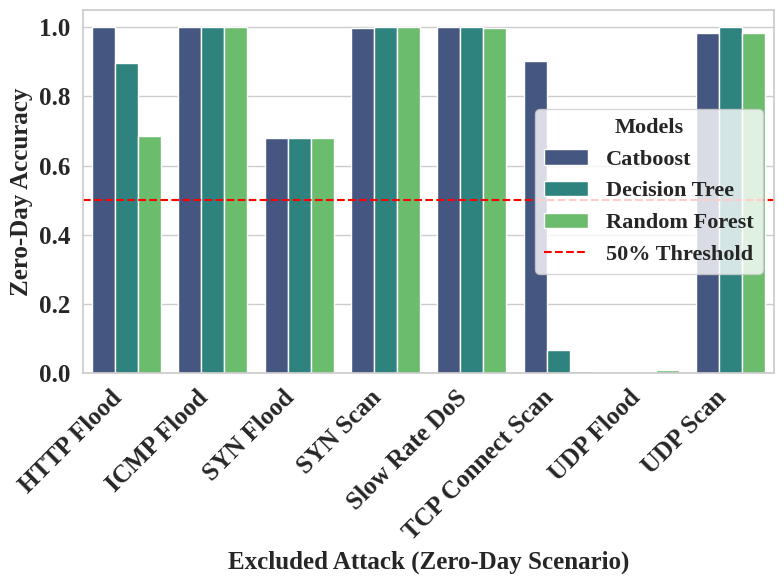

In [9]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font="serif")

models_to_keep = ['Catboost', 'Decision Tree', 'Random Forest']
df_filtered = df[df['Model'].isin(models_to_keep)].copy()
df_plot = df_filtered.groupby(['Ataque Zero-Day', 'Model'])['ZD - Accuracy'].mean().reset_index()


plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x='Ataque Zero-Day',
    y='ZD - Accuracy',
    hue='Model',
    data=df_plot,
    palette='viridis'
)

plt.ylabel('Zero-Day Accuracy', fontsize=18)
plt.xlabel('Excluded Attack (Zero-Day Scenario)', fontsize=18)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='50% Threshold')


plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    title='Models',
    loc='center right',
    fontsize=16,
    ncol=1,
    title_fontsize=16
)


plt.rcParams.update({
    "font.family": "serif",
    "font.sans-serif": ["Liberation Serif"],
    "font.weight": "bold",
    "axes.labelweight": "bold",
})

plt.tight_layout()
plt.savefig('zero_day_accuracy_fixed.pdf', format='pdf', bbox_inches='tight')

plt.show()